In [1]:
import subprocess
import os
import math
from functions.basefunctions import *
from collections import defaultdict
import numpy as np
import time 

kbT_RNA = 0.6163207755

In [8]:
import pickle

with open('../data/fRNAhammingdistance.pkl', 'rb') as f:
    fRNAhammingdistance = pickle.load(f)

with open('../data/fRNAprob2.pkl', 'rb') as f:
    fRNAprob2 = pickle.load(f)

with open('../data/fRNAprob1.pkl', 'rb') as f:
    fRNAprob1 = pickle.load(f)

with open('../data/fRNAfolds.pkl', 'rb') as f:
    fRNAfolds = pickle.load(f)

with open('../data/selected_for_analysis.pkl','rb') as f:
    selected_for_analysis = pickle.load(f)

In [9]:
len(fRNAhammingdistance), len(fRNAprob2)

(311016, 311016)

In [20]:
diagonal_distances = {}
for x, y,key1,key2 in zip(fRNAprob1.values(), fRNAprob2.values(), fRNAprob1.keys(), fRNAprob2.keys()):
    if key1 == key2:
        distance = np.sqrt((x - 0.5)**2 + (y - 0.5)**2)/np.sqrt(2)
        diagonal_distances[key1] = distance

#  Significant fRNAs

From selected_for_analysis, make site-scanning mutational neighbourhood for each sequence uing sitescanninganalysis.py and then run the code below to check their significance. Store in merged_dict. 
To simplify, we share merged_dict.

In [ ]:
import glob
import pandas as pd
import re
import numpy as np
from scipy.stats import norm
from collections import defaultdict
import pickle
# Path to the data folder
data_folder = '../data/'

# Pattern to match the files
file_pattern = data_folder + 'selected_for_analysis*_ssize10000.pkl'

# List to store p-values from all files
merged_dict = defaultdict(dict)


files = glob.glob(file_pattern)

left_names = selected_for_analysis
# Loop through each file and extract probs2
for file in files:
    match = re.search(r'selected_for_analysis(\d+)_ssize10000', file)
    if match:
        seq_number = int(match.group(1))
        # Read the file into a DataFrame
        with open(file, 'rb') as f:
            data = pickle.load(f)
        
        # Extract probs2 and append to the list
        probs2 = list(data['probs2'])
        observed_value = fRNAprob2[tuple(left_names[seq_number])]  # Replace with your specific value
        
        mean = np.mean(probs2)
        std_dev = np.std(probs2)

        # Compute the z-score for the observed value
        z_score = (observed_value - mean) / std_dev

        # One-tailed p-value (upper-tail)
        p_value_upper = 1 - norm.cdf(z_score)
        if p_value_upper < 0.05:
            print(seq_number, tuple(left_names[seq_number]), p_value_upper)
            merged_dict[tuple(left_names[seq_number])][(fRNAhammingdistance[tuple(left_names[seq_number])],fRNAprob1[tuple(left_names[seq_number])],fRNAprob2[tuple(left_names[seq_number])])] = p_value_upper

# fRNA significant with BH correction

In [13]:
with open('../data/merged_dict.pkl', 'rb') as f:
    merged_dict= pickle.load(f)

In [14]:
sorted_merged_dict = dict(sorted(merged_dict.items(), key=lambda item: list(item[1].values())[0]))


In [17]:
import numpy as np

def find_first_false_streak(comparison):
    for idx in range(len(comparison)):
        if all(not val for val in comparison[idx:]):
            return idx
    return None

def false_discovery_control(ps, *, axis=0, method='bh'):

    ps = np.asarray(ps)
    if method == 'bh':
        # Benjamini-Hochberg procedure
        shape = ps.shape
        ps = np.sort(ps, axis=axis)
        n = ps.shape[axis]
        i = np.arange(1, n + 1)
        threshold = 0.1*i/ len(selected_for_analysis)
        comparison = ps <= threshold
        false_indices = np.where(comparison == False)[0]
        first_false_streak_index = find_first_false_streak(comparison)
        if first_false_streak_index is not None:
            print(f"Index where comparison becomes consistently False: {first_false_streak_index}")
        else:
            print("No consistent False streak found in comparison")
        return comparison
    else:
        raise ValueError(f"Unknown method: {method}")

# Example usage
p_values = [list(inner_dict.values())[0] for inner_dict in sorted_merged_dict.values()]
comparison = false_discovery_control(p_values, method='bh')
print(comparison)

Index where comparison becomes consistently False: 145
[ True  True False ... False False False]


In [16]:
count = -1
sigBH = {}
for k,v in sorted_merged_dict.items():
    count+=1
    sigBH[k] = v
    if count == 146: break

# Plot for selected and significant with ranking of distance d

In [22]:
import numpy as np

hamming = []
distance = []
for name in selected_for_analysis:
    hamming.append(fRNAhammingdistance[tuple(name)])
    distance.append(diagonal_distances[tuple(name)])

# Convert distance list to numpy array for sorting
distance_array = np.array(distance)

# Get the sorted indices of the distances
sorted_indices = distance_array.argsort()

# Sort names according to the sorted indices
sorted_names = [selected_for_analysis[i] for i in sorted_indices]
sorted_distance = [distance[i] for i in sorted_indices]
rank_sig_d = []
distance_sig = []
rank = -1
rank_distribution_d = 0
distance_distribution = 0
for indx,name in zip(sorted_indices,sorted_names):
    rank +=1
    name = tuple(name)
    if name in list(sigBH.keys()):
        rank_sig_d.append(rank)
        distance_sig.append(distance[indx])
        if name == ('FR001310|D16617|Hepatitis C stem-loop IV','CTTTGCCTACTCCTACTCACCGTAGGGGTAGGCGTTT'):
            rank_distribution_d = rank
            distance_distribution = distance[indx]

hamming_array = np.array(hamming)

# Get the sorted indices of the distances
sorted_indices = hamming_array.argsort()

# Sort names according to the sorted indices
sorted_names = [selected_for_analysis[i] for i in sorted_indices]
sorted_hamming = [hamming[i] for i in sorted_indices]
rank_sig = []
hamming_sig = []
rank = -10
rank_distribution_h = 0
hamming_distribution = 0 
for indx,name in zip(sorted_indices,sorted_names):
    rank +=1
    name = tuple(name)
    if name in list(sigBH.keys()):
        rank_sig.append(rank)
        hamming_sig.append(hamming[indx])
        if name == ('FR001310|D16617|Hepatitis C stem-loop IV','CTTTGCCTACTCCTACTCACCGTAGGGGTAGGCGTTT'):
            rank_distribution_h = rank
            hamming_distribution = hamming[indx]
            print(hamming_distribution)

0.05405405405405406


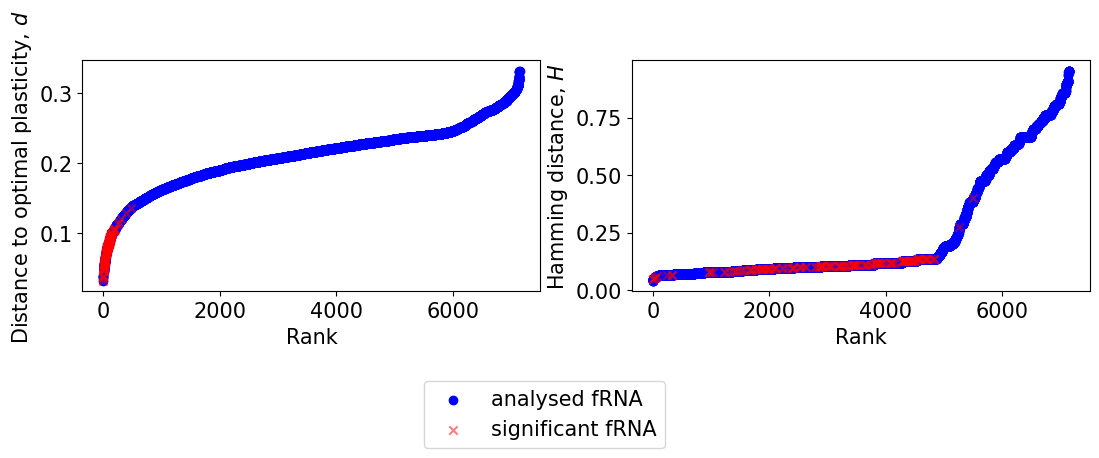

In [24]:
from matplotlib import pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 3))
ax1.scatter(np.arange(0,len(distance)),sorted_distance, c='blue', marker='o', alpha=1.0, label='analysed fRNA')
ax1.scatter(rank_sig_d,distance_sig, c='red', marker='x', alpha=0.5, label='significant fRNA')
#ax1.scatter(rank_distribution_d, distance_distribution, c='black', marker='s', alpha=1.0)
ax1.set_xlabel('Rank', fontsize=15)
ax1.set_ylabel('Distance to optimal plasticity, $d$', fontsize=15)
ax1.tick_params(axis='x', labelsize=15)
ax1.tick_params(axis='y', labelsize=15)


ax2.scatter(np.arange(0,len(hamming)),sorted_hamming, c='blue', marker='o', alpha=1.0, label='analysed fRNA')
ax2.scatter(rank_sig,hamming_sig, c='red', marker='x', alpha=0.5, label='significant fRNA')
#ax2.scatter(rank_distribution_h, hamming_distribution, c='black', marker='s', alpha=1.0)
ax2.set_xlabel('Rank', fontsize=15)
ax2.set_ylabel('Hamming distance, $H$', fontsize=15)
ax2.tick_params(axis='x', labelsize=15)
ax2.tick_params(axis='y', labelsize=15)
plt.subplots_adjust(hspace=15) 
handles, labels = [], []
for ax in [ax1,ax2]:
    for handle, label in zip(*ax.get_legend_handles_labels()):
        if label not in labels:
            handles.append(handle)
            labels.append(label)

fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.38, -0.3), fontsize=15)